In [5]:
import oqupy
import oqupy.operators as op
import numpy as np
from oqupy.iTEBD_TEMPO_useoqupybath import iTEBD_TEMPO_oqupy
from oqupy.process_tensor import TTInvariantProcessTensor
from oqupy.tti_tempo import TTITempo
from oqupy.tti_tempo import TTITempoCounting
import matplotlib.pyplot as plt


from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
from scipy.optimize import minimize,Bounds

pt_parameters = {'epsrel':10**(-7),
                 'alpha':0.1,
                 'omega_cutoff':1,                 
                 'temp':0.131,
                 'dt':0.25}

omega_cutoff = pt_parameters['omega_cutoff']
alpha = pt_parameters['alpha']
temperature = pt_parameters['temp']
epsrel = pt_parameters['epsrel']
# dt = 1./omega_cutoff/np.sqrt(3)
dt=pt_parameters['dt']

tcut=27

Rho_0=oqupy.operators.spin_dm('x+')

# spectral density (without cutoff)
def j(w):
    return 2*alpha*w


In [6]:
correlations = oqupy.PowerLawSD(alpha=alpha,
                                zeta=1,
                                cutoff=omega_cutoff,
                                cutoff_type='exponential',
                                temperature=temperature)
bath = oqupy.Bath(op.sigma("z")/2.0, correlations)
parameters=oqupy.TempoParameters(dt=dt,epsrel=epsrel,dkmax=int(tcut/dt)+1)

In [7]:
u=0.01
correlationscf=oqupy.bath_correlations.CustomCountingSD(j_function=j,cutoff=omega_cutoff,u=u,
                                                 cutoff_type='exponential',temperature=temperature)

bathcf = oqupy.Bath(op.sigma("z")/2.0, correlationscf)

In [8]:
# converged parameters for different protocol times 
protocol_times=[20,50,70,100]

pt_var=TTITempo(bath,start_time=0.0,parameters=parameters)
process_tensor_var = pt_var.get_process_tensor()

pt_varcf=TTITempoCounting(bathcf,start_time=0.0,parameters=parameters)
process_tensor_varcf = pt_varcf.get_process_tensor()


building influence functional:  21%|██        | 23/109 [00:00<00:00, 218.25it/s]

building influence functional: 100%|██████████| 109/109 [00:20<00:00,  5.34it/s]


rank  378


/Users/eoinoneill/Desktop/PhD/ITT-tempo/OQuPy/oqupy/bath_correlations.py:1165: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  im_int += integrate.quad(im_integrand,
building influence functional:  16%|█▌        | 17/109 [00:00<00:00, 169.87it/s]

building influence functional: 100%|██████████| 109/109 [00:21<00:00,  5.18it/s]


rank  386


--> Compute dynamics:
100.0%   10 of   10 [########################################] 00:00:00
Elapsed time: 0.9s
--> Compute dynamics:
100.0%   10 of   10 [########################################] 00:00:01
Elapsed time: 1.2s
0.7124471404919689


/var/folders/s8/7dsl0tws32199pt1sh7flrsw0000gn/T/ipykernel_1028/2302317780.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


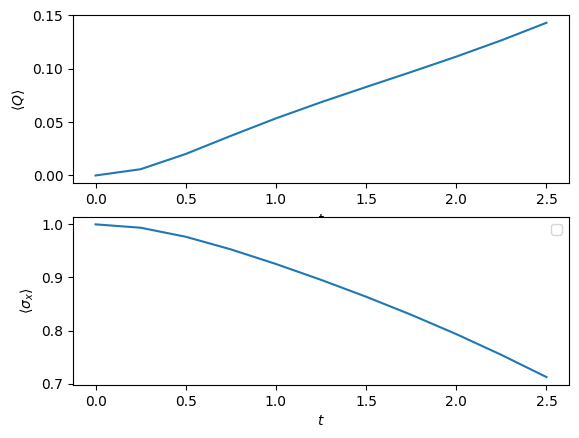

In [9]:
num_steps=10
tot_time=num_steps*dt
fig,axs=plt.subplots(2)

def hamiltonian_t(t):
    return pt_parameters['omega_cutoff']*op.sigma('x')*t/2 *(1/(num_steps*dt))
system = oqupy.TimeDependentSystem(hamiltonian_t)

# compute dynamics

dynamics=oqupy.compute_dynamics(
process_tensor=process_tensor_var,        
system=system,
initial_state=Rho_0,
start_time=0,
num_steps=num_steps)
t, s_x = dynamics.expectations(op.sigma('x'), real=True)

# compute heats

dynamicscf = oqupy.compute_dynamics(
process_tensor=process_tensor_varcf,        
system=system,
initial_state=Rho_0,
start_time=0,
num_steps=num_steps)

heats=dynamicscf.states.trace(axis1=1,axis2=2).imag/u

axs[0].plot(t,heats,label=tot_time)
axs[0].set_xlabel(r'$t$')
axs[0].set_ylabel(r'$\langle Q \rangle$')
axs[1].plot(t,s_x)
axs[1].set_xlabel(r'$t$')
axs[1].set_ylabel(r'$\langle \sigma_x \rangle$')
print(s_x[-1])
plt.legend()
plt.show()

In [15]:
def discrete_hamiltonian(hx):
    return hx*op.sigma('x')/2
system = oqupy.ParameterizedSystem(discrete_hamiltonian)

target_derivative = -1j*np.identity(2)/u

In [7]:
from oqupy.gradient import state_gradient_coarse,state_gradient
h_z = np.ones(2*10)


gradcoarse=state_gradient_coarse(
        system=system,
        initial_state=Rho_0,
        target_derivative=target_derivative,
        process_tensors=[process_tensor_var],
        parameters=np.vstack(h_z),
        opt_steps=[1,2,3,4,5,6,7,8,9,10],
        num_steps=10,
        progress_type='silent')

grad=state_gradient(
        system=system,
        initial_state=Rho_0,
        target_derivative=target_derivative,
        process_tensors=[process_tensor_var],
        parameters=np.vstack(h_z),
        num_steps=10,
        progress_type='silent')



/Users/eoinoneill/Desktop/PhD/ITT-tempo/OQuPy/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/eoinoneill/Desktop/PhD/ITT-tempo/OQuPy/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


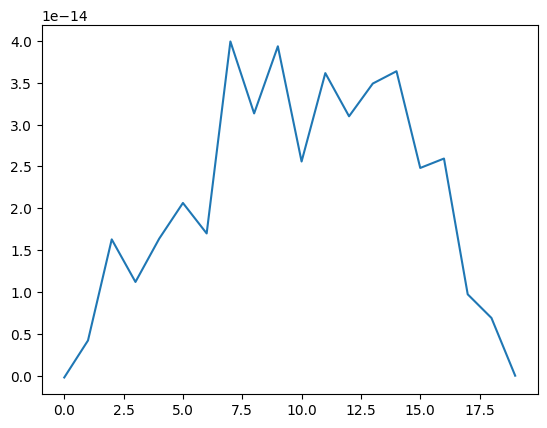

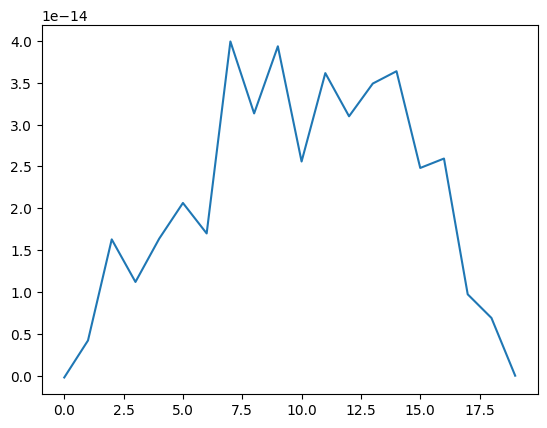

20
20


In [8]:
plt.plot(gradcoarse['gradient'])
plt.show()
plt.plot(grad['gradient'])
plt.show()
print(len(grad['gradient']))
print(len(gradcoarse['gradient']))

In [12]:
from oqupy.gradient import state_gradient_coarse

# Cost Function
num_params=1

def heatandgradcoarse(paras,process_tensor,num_steps,opt_steps):
    """""
    Take a numpy array [hx0, hz0, hx1, hz1, ...] over full timesteps and
    return the fidelity and gradient of the fidelity to the global target_derivative
    """
    # optimiser accepts list over coarse-grained timestesp
    # converted to list over all half-timesteps by reshaping using given indices
    # gradient then returns derivatives over coarse-gradined timesteps

    result=[paras[0]]
    prev=0
    for i,step in enumerate(opt_steps):
        element=[paras[i]]
        repeat_times=2*step+2-prev
        result.extend(element*repeat_times)
        prev=2*step+2
    control_params=result # input to gradient


    control_params=np.vstack((control_params))

    gradient_dict = state_gradient_coarse(
        system=system,
        initial_state=Rho_0,
        target_derivative=target_derivative,
        process_tensors=[process_tensor],
        parameters=control_params,
        opt_steps=opt_steps,
        num_steps=num_steps,
        progress_type='silent')
    
    fs=gradient_dict['final_state']
    gps=np.array(gradient_dict['gradient'])

    heat=np.trace(fs).imag/u

    # Return the minus the gradient as infidelity is being minimized 
    return heat,(1.0*gps.reshape((-1)).real).tolist()

In [13]:
def division_indices(K,N):  
    # function which provides appropriate indices to equally divide N parameters into K divisions
    # K-number of divisions # N-number of timesteps
    return [((i + 1) * N) // K - 0 for i in range(K)]

print(division_indices(3,10))

[3, 6, 10]


In [11]:
import numpy as np
from scipy.optimize import minimize
import time
from oqupy.gradient import state_gradient_coarse

def heatandgrad(paras, process_tensor, num_steps, opt_steps):
    """
    Take a numpy array [hx0, hz0, hx1, hz1, ...] over full timesteps and
    return the fidelity and gradient of the fidelity to the global target_derivative.
    """
    result=[]
    result.extend([paras[0]]* 2*opt_steps[0])
    
    # Convert K-controls to list over 2N timesteps
    for i in range(1,len(paras)):
        step_diff = opt_steps[i] - opt_steps[i-1]
        repeat_times = 2 * step_diff
        result.extend([paras[i]] * repeat_times)

    # Convert to numpy array
    control_params=np.vstack((result))

    # Perform state gradient computation
    gradient_dict = state_gradient_coarse(
        system=system,
        initial_state=Rho_0,
        target_derivative=target_derivative,
        process_tensors=[process_tensor],
        parameters=control_params,
        opt_steps=opt_steps,
        num_steps=num_steps,
        progress_type='silent'
    )

    # Extract the final state and gradient
    fs = gradient_dict['final_state']
    gps = gradient_dict['gradient']

    # Compute heat (imaginary part of trace divided by u)
    heat = np.trace(fs).imag / u

    # Step 2: Coarse-grain by summing the groups
    final_derivs_coarse = []
    group_sum = np.sum(gps[0:2*opt_steps[0]])
    final_derivs_coarse.append(group_sum)
    prev = 2*opt_steps[0]
    for i in range(1,len(paras)):
        step_diff = opt_steps[i] - opt_steps[i-1]
        count = 2 * step_diff
        group_sum = np.sum(gps[prev:prev + count])
        final_derivs_coarse.append(group_sum)
        prev += count

    gps = np.array(final_derivs_coarse).reshape(-1, 1)

    return heat, (1.0 * gps.reshape((-1)).real).tolist()

# Simplified division indices function
def division_indices(K, N):
    return [((i + 1) * N) // K for i in range(K)]

In [54]:
import time
import cProfile, pstats, io
from pstats import SortKey


#pr = cProfile.Profile()
#pr.enable()
#pt=TTITempoCounting(bathcf,start_time=0.0,parameters=parameters)
#pr.disable()
#process_tensor_tebd = pt.get_process_tensor()
#pr.dump_stats('testingProf.prof')
protocol_times=[20,50,70,100]

opt_dict={protocol_times[0]:[],
                 protocol_times[1]:[], 
                 protocol_times[2]:[],
                 protocol_times[3]:[]}

runtime_dict={protocol_times[0]:[],
                 protocol_times[1]:[], 
                 protocol_times[2]:[],
                 protocol_times[3]:[]}


for t_prot in protocol_times:
    num_steps=int(t_prot/process_tensor_varcf.dt)
    division_list=[num_steps,num_steps//2,10,1]
    
    for num_divisions in division_list:
        opt_steps=division_indices(num_divisions,num_steps)

        #parameter_list=np.linspace(0,omega_cutoff,num_divisions) # list of size K
        parameter_list=-np.ones(num_divisions)*0

        start = time.time()

        optimization_result = minimize(
                                fun=heatandgrad,
                                x0=parameter_list,
                                args=(process_tensor_varcf,num_steps,opt_steps),
                                method='l-bfgs-b',
                                jac=True,
                                options = {'disp':True, 'gtol': 7e-04}
        )
        end = time.time()
        #opt_runtimes.append(end-start)

        opt_dict[t_prot].append(optimization_result)

        runtime_dict[t_prot].append(end-start)

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           80     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  9.97786D-02    |proj g|=  1.24993D-02


 This problem is unconstrained.



At iterate    1    f=  6.08899D-02    |proj g|=  9.48179D-03

At iterate    2    f=  2.72217D-02    |proj g|=  5.19289D-03

At iterate    3    f=  1.55206D-02    |proj g|=  3.21249D-03

At iterate    4    f=  9.78768D-03    |proj g|=  1.84527D-03

At iterate    5    f=  7.31110D-03    |proj g|=  1.49456D-03

At iterate    6    f=  5.70192D-03    |proj g|=  1.28011D-03

At iterate    7    f=  4.20640D-03    |proj g|=  8.63988D-04

At iterate    8    f=  3.29357D-03    |proj g|=  8.34687D-04

At iterate    9    f=  2.60682D-03    |proj g|=  6.90042D-04

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
   80      9     10   

 This problem is unconstrained.


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           40     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  9.97786D-02    |proj g|=  2.44864D-02

At iterate    1    f=  5.11373D-02    |proj g|=  1.71714D-02

At iterate    2    f=  2.65395D-02    |proj g|=  8.71514D-03

At iterate    3    f=  1.55086D-02    |proj g|=  4.75568D-03

At iterate    4    f=  1.05838D-02    |proj g|=  3.26873D-03

At iterate    5    f=  8.23546D-03    |proj g|=  2.63732D-03

At iterate    6    f=  6.33932D-03    |proj g|=  2.02387D-03

At iterate    7    f=  4.55265D-03    |proj g|=  2.12702D-03

At iterate    8    f=  3.21823D-03    |proj g|=  1.89860D-03

At iterate    9    f=  2.34719D-03    |proj g|=  1.04292D-03

At iterate   10    f=  1.57429D-03    |proj g|=  1.13742D-03

At iterate   11    f=  1.18868D-03    |proj g|=  1.80856D-03

At iterate   12    f=  7.83646D-04    |proj g|=  7.31766D-04

At iterate   13    f=  5.1

...

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =          200     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  1.01475D-01    |proj g|=  2.45021D-02

At iterate    1    f=  5.04224D-02    |proj g|=  1.73934D-02

At iterate    2    f=  1.69375D-02    |proj g|=  8.44846D-03

At iterate    3    f= -1.23573D-03    |proj g|=  4.63496D-03

At iterate    4    f= -8.07517D-03    |proj g|=  4.19896D-03

At iterate    5    f= -1.09821D-02    |proj g|=  2.79483D-03

At iterate    6    f= -1.23890D-02    |proj g|=  2.56128D-03

At iterate    7    f= -1.37931D-02    |proj g|=  2.01131D-03

At iterate    8    f= -1.45458D-02    |proj g|=  2.42435D-03

At iterate    9    f= -1.53614D-02    |proj g|=  1.46381D-03

At iterate   10    f= -1.59816D-02    |proj g|=  1.15901D-03

At iterate   11    f= -1.64767D-02    |proj g|=  1.18873D-03

At iterate   12    f= -1.67069D-02    |proj g|=  1.93499D-03

At iterate   13    f= -1.7

 This problem is unconstrained.



At iterate    1    f=  3.34180D-02    |proj g|=  6.84807D-02

At iterate    2    f=  1.69357D-02    |proj g|=  3.96352D-02

At iterate    3    f=  1.00258D-02    |proj g|=  2.52524D-02

At iterate    4    f=  8.84746D-03    |proj g|=  1.68621D-02

At iterate    5    f=  8.29212D-03    |proj g|=  5.98137D-03

At iterate    6    f=  7.86328D-03    |proj g|=  6.76013D-03

At iterate    7    f=  7.31791D-03    |proj g|=  1.64060D-02

At iterate    8    f=  6.79828D-03    |proj g|=  7.10722D-03

At iterate    9    f=  6.60568D-03    |proj g|=  3.71710D-03

At iterate   10    f=  6.44256D-03    |proj g|=  5.34853D-03

At iterate   11    f=  6.01951D-03    |proj g|=  1.09635D-02

At iterate   12    f=  5.72078D-03    |proj g|=  2.47293D-02

At iterate   13    f=  4.83461D-03    |proj g|=  2.33040D-02

At iterate   14    f=  4.31623D-03    |proj g|=  1.58622D-02

At iterate   15    f=  3.63428D-03    |proj g|=  4.97869D-03

At iterate   16    f=  3.56236D-03    |proj g|=  2.35187D-03

At iter

 This problem is unconstrained.


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            1     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  1.01475D-01    |proj g|=  4.95515D-01

At iterate    1    f=  3.30328D-02    |proj g|=  1.54022D-02

At iterate    2    f=  3.27282D-02    |proj g|=  5.31396D-03

At iterate    3    f=  3.26480D-02    |proj g|=  4.76854D-03

At iterate    4    f=  2.52847D-02    |proj g|=  3.95897D-03

At iterate    5    f=  2.42441D-02    |proj g|=  1.53374D-03

At iterate    6    f=  2.42420D-02    |proj g|=  4.06651D-05

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nac

In [14]:
# more optimal binning according to controls

num_steps = 280  # total steps (2N)
K = 20          # total partitions

# Define partition counts per region
start_K = 9
middle_K = 2
end_K = 9

print(start_K + middle_K + end_K)

# Sanity check
assert start_K + middle_K + end_K == K

middle_start=40
end_start=240

# Define region boundaries
start = np.linspace(0, middle_start, start_K + 1, dtype=int)[1:]        # exclude 0, keep 10
middle = np.linspace(middle_start, end_start, middle_K + 1, dtype=int)[1:]     # exclude 10, keep 60
end = np.linspace(end_start, num_steps, end_K + 1, dtype=int)[1:]           # exclude 60, keep 70

# Combine all steps
opt_steps = np.concatenate((start, middle, end)).tolist()

# Final check
assert opt_steps[-1] == num_steps, f"Last step {opt_steps[-1]} ≠ {num_steps}"
assert len(opt_steps) == K, f"Length {len(opt_steps)} ≠ {K}"

print("opt_steps =", opt_steps)
print(len(opt_steps))

20
opt_steps = [4, 8, 13, 17, 22, 26, 31, 35, 40, 140, 240, 244, 248, 253, 257, 262, 266, 271, 275, 280]
20


In [16]:
for num_divisions in [20]:
    num_steps=int(t_prot/process_tensor_varcf.dt)

    bounds = np.zeros((num_divisions*num_params,2))

    #for i in range(0, num_params*num_divisions,num_params):
        #bounds[i] = x_bound
    #print(opt_steps)
    #print(len(opt_steps))

    #parameter_list=np.linspace(0,omega_cutoff,num_divisions) # list of size K
    parameter_list=np.ones(num_divisions)*0
    #print(parameter_list)
    start = time.time()
    #print(num_steps)
    optimization_result = minimize(
                            fun=heatandgrad,
                            x0=parameter_list,
                            args=(process_tensor_varcf,num_steps,opt_steps),
                            method='l-bfgs-b',
                            jac=True,
                            options = {'disp':True, 'gtol': 7e-04}
    )
    end = time.time()
    opt_runtimes.append(end-start)

    opt_dict[num_divisions]=optimization_result

    min_heats.append(optimization_result.fun)

    print("The minimal heat was found to be : ",optimization_result.fun)

    print("The Jacobian was found to be : ",optimization_result.jac)

    

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           20     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  1.00875D-01    |proj g|=  1.87813D-01


 This problem is unconstrained.



At iterate    1    f=  9.01960D-02    |proj g|=  1.68850D-01

At iterate    2    f=  7.76874D-02    |proj g|=  7.55668D-02

At iterate    3    f=  6.74648D-02    |proj g|=  7.90211D-02

At iterate    4    f=  5.18664D-02    |proj g|=  1.33418D-01

At iterate    5    f=  3.02198D-02    |proj g|=  1.09115D-01

At iterate    6    f=  1.57513D-02    |proj g|=  7.13229D-02

At iterate    7    f=  7.68322D-03    |proj g|=  1.79182D-02

At iterate    8    f=  4.78154D-03    |proj g|=  1.93842D-02

At iterate    9    f=  2.92661D-04    |proj g|=  1.02828D-02

At iterate   10    f= -3.20975D-03    |proj g|=  9.44521D-03

At iterate   11    f= -4.23009D-03    |proj g|=  5.83321D-03

At iterate   12    f= -4.70081D-03    |proj g|=  4.41839D-03

At iterate   13    f= -4.82865D-03    |proj g|=  1.30607D-03

At iterate   14    f= -4.90207D-03    |proj g|=  2.94949D-03

At iterate   15    f= -4.91975D-03    |proj g|=  7.61502D-03

At iterate   16    f= -4.95088D-03    |proj g|=  5.10246D-03

At iter

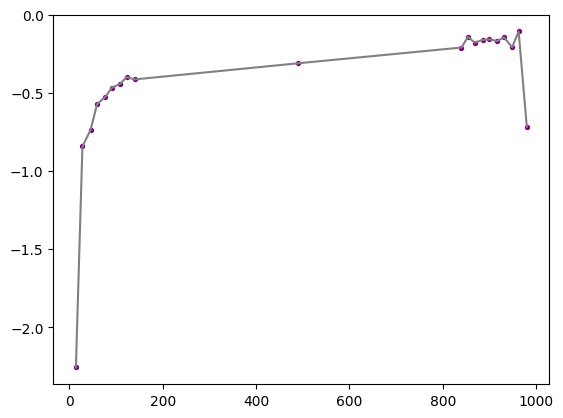

In [18]:
opt_res=opt_dict[20]
times=[step / 20 * t_prot for step in opt_steps]

plt.scatter(times,opt_res.x,s=8,c='purple')
plt.plot(times,opt_res.x,c='gray')

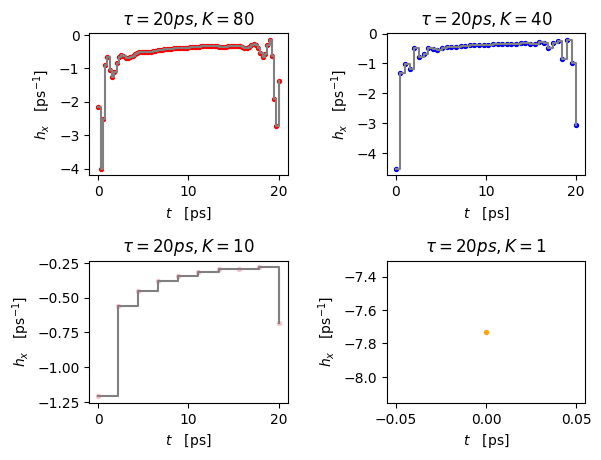

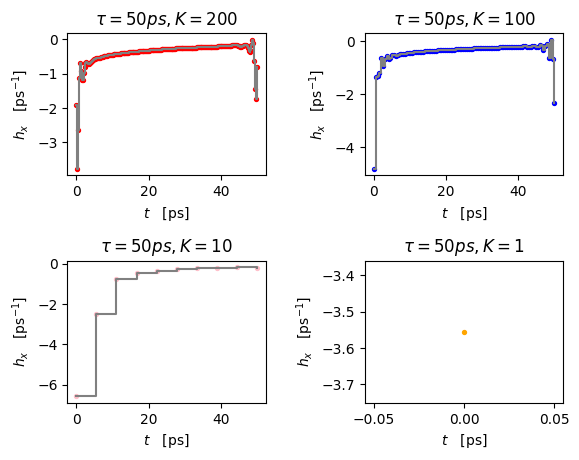

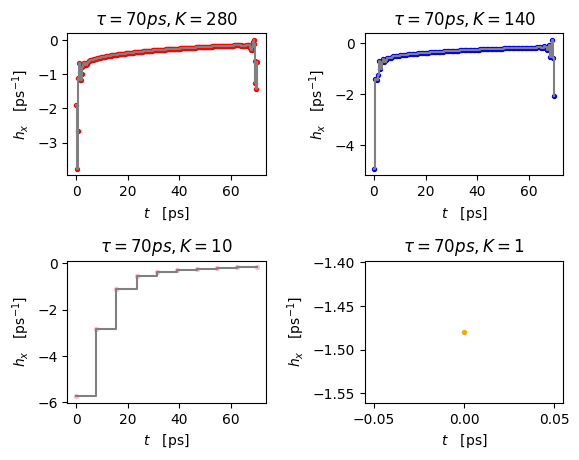

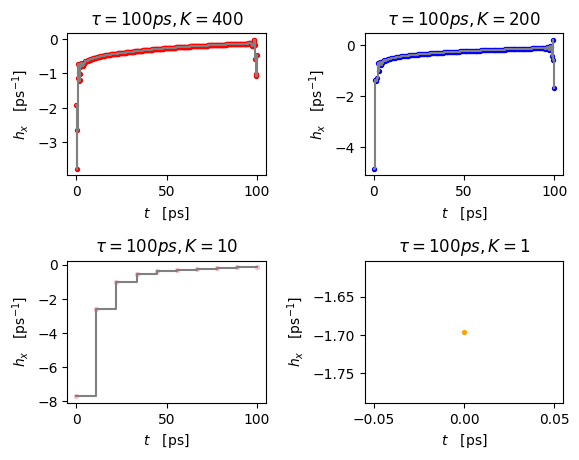

<function matplotlib.pyplot.title(label: 'str', fontdict: 'dict[str, Any] | None' = None, loc: "Literal['left', 'center', 'right'] | None" = None, pad: 'float | None' = None, *, y: 'float | None' = None, **kwargs) -> 'Text'>

In [62]:
cs=['red','blue','pink','orange','green']
controlfigs_dict={protocol_times[0]:[],
                 protocol_times[1]:[], 
                 protocol_times[2]:[],
                 protocol_times[3]:[]}


for t_prot in protocol_times:
    fig,axs=plt.subplots(2,2)
    fig.subplots_adjust(hspace=0.6,wspace=0.5)
    graphpos=[axs[0,0],axs[0,1],axs[1,0],axs[1,1]]

    num_steps=int(t_prot/process_tensor_varcf.dt)
    division_list=[num_steps,num_steps//2,10,1]
    
    for i,num_divisions in enumerate(division_list):
        opt_res=opt_dict[t_prot][i]
        graphpos[i].set_title(r'$\tau={0} ps, K={1}$'.format(t_prot,num_divisions))
        graphpos[i].scatter(np.linspace(0,t_prot,len(opt_res.x)),opt_res.x,s=8,c=cs[i])
        graphpos[i].step(np.linspace(0,t_prot,len(opt_res.x)),opt_res.x,c='gray',where='post')
        graphpos[i].set_xlabel(r'$t \quad[\text{ps}]$')
        graphpos[i].set_ylabel(r'$h_x \quad[\text{ps}^{-1}]$')
    plt.show()
        

#plt.scatter([num_steps,num_steps//2,10,1],min_heats[-4:])
# check if these dynamics are converged 

plt.title
    

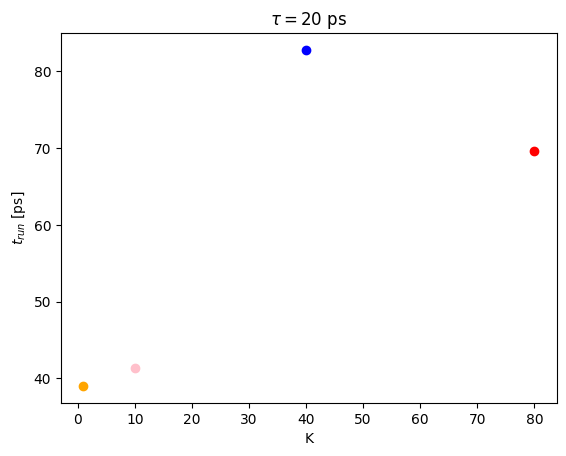

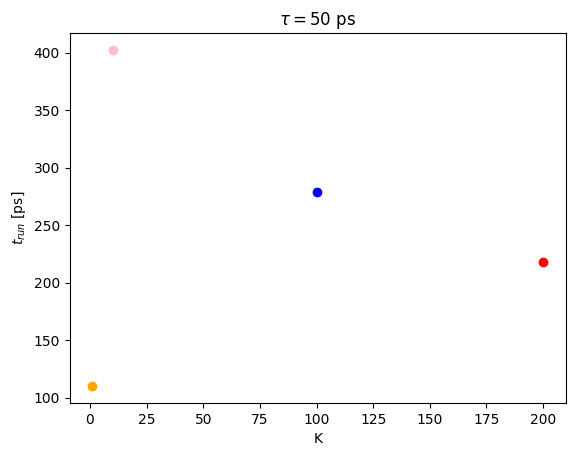

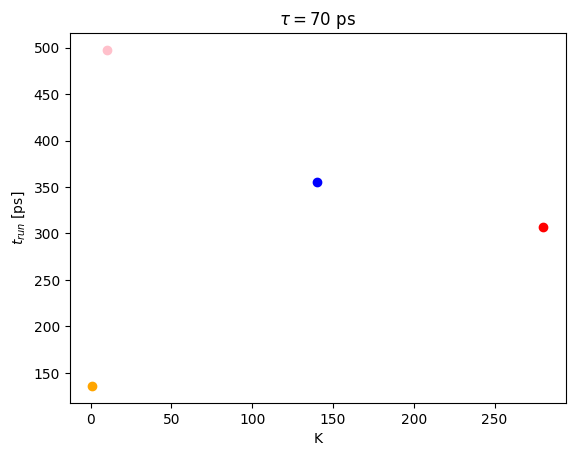

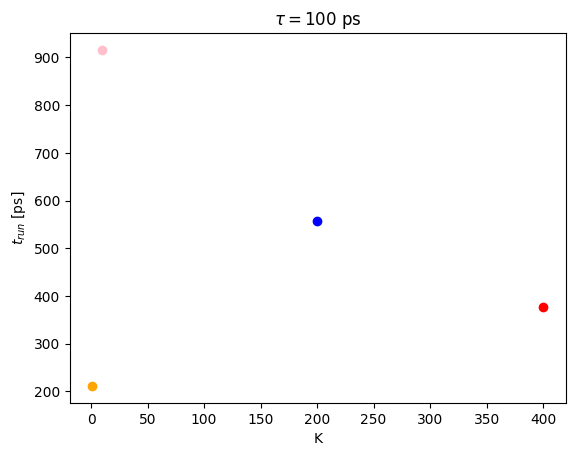

In [68]:
for t_prot in protocol_times:
    num_steps=int(t_prot/process_tensor_varcf.dt)
    division_list=[num_steps,num_steps//2,10,1]
    plt.title(r'$\tau={0}$ ps'.format(t_prot))
    for i,run_time in enumerate(runtime_dict[t_prot]):
        plt.scatter(division_list[i],run_time,c=cs[i])
    plt.xlabel('K')
    plt.ylabel(r'$t_{run}$ [ps]')
    plt.show()

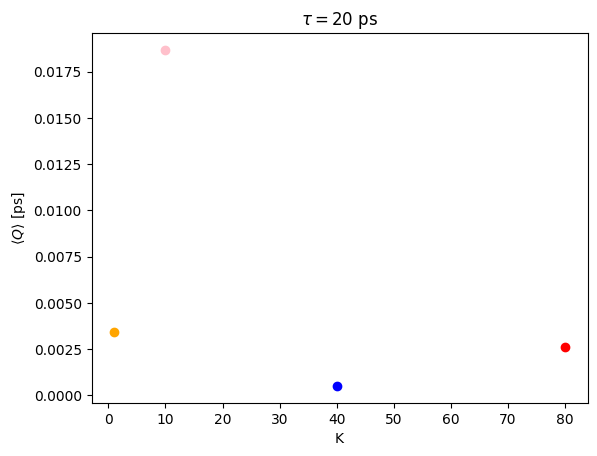

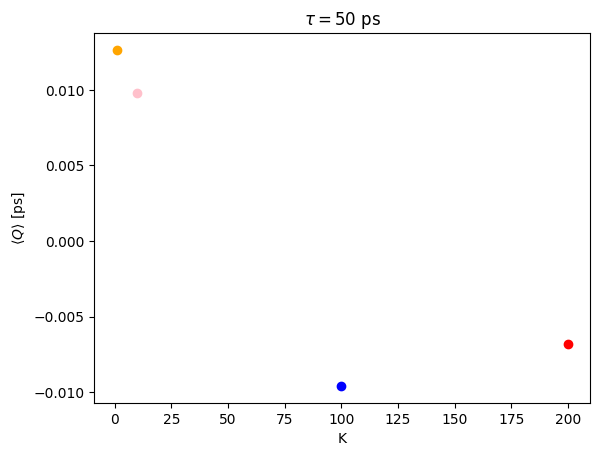

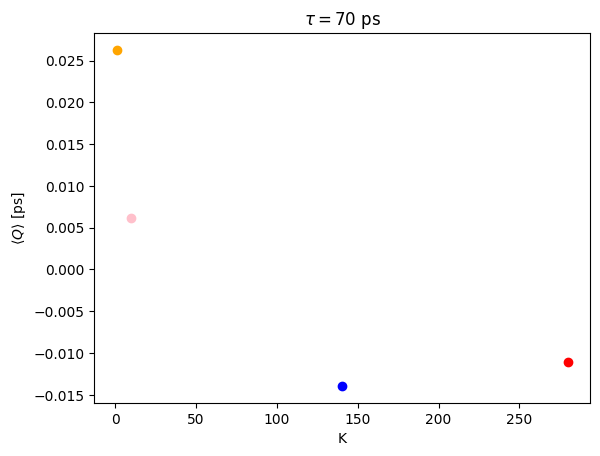

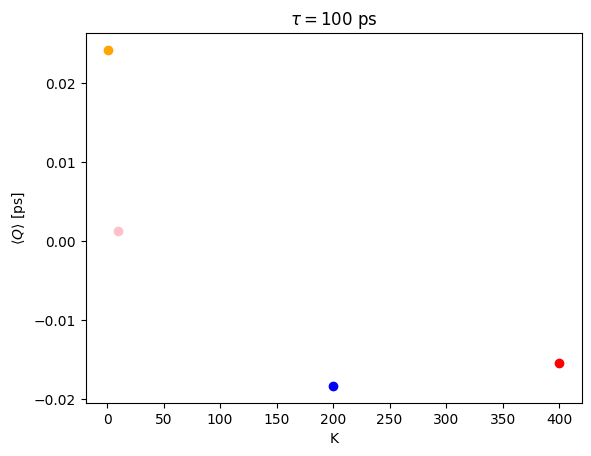

In [69]:
for t_prot in protocol_times:
    num_steps=int(t_prot/process_tensor_varcf.dt)
    division_list=[num_steps,num_steps//2,10,1]
    plt.title(r'$\tau={0}$ ps'.format(t_prot))
    for i,num_divisions in enumerate(division_list):
        heat=opt_dict[t_prot][i].fun
        plt.scatter(num_divisions,heat,c=cs[i])
    plt.xlabel('K')
    plt.ylabel(r'$\langle Q \rangle$ [ps]')
    plt.show()

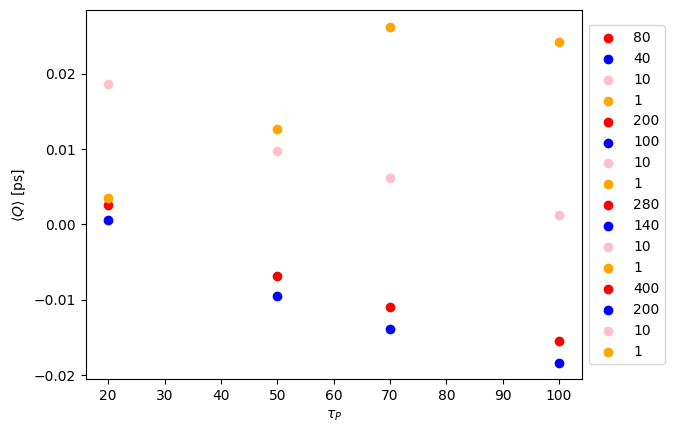

In [78]:
for t_prot in protocol_times:
    num_steps=int(t_prot/process_tensor_varcf.dt)
    division_list=[num_steps,num_steps//2,10,1]
    for i,num_divisions in enumerate(division_list):
        heat=opt_dict[t_prot][i].fun
        plt.scatter(t_prot,heat,c=cs[i],label=num_divisions)
        
    plt.xlabel(r'$\tau_P$')
    plt.ylabel(r'$\langle Q \rangle$ [ps]')
plt.legend(loc='center left',bbox_to_anchor=(1, 0.5))
plt.show()

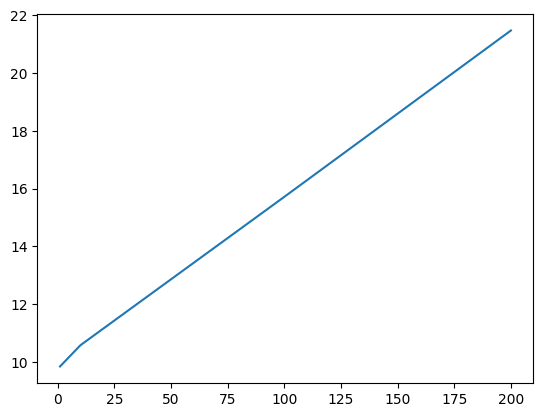

In [20]:
from oqupy.gradient import state_gradient_coarse
import cProfile,time
grad_runtimes=[]


t_prot=50
num_steps=num_steps=int(t_prot/process_tensor_varcf.dt)

for i,num_divisions in enumerate([num_steps,num_steps//2,10,1]):
        
        start=time.time()
        pr = cProfile.Profile()
        pr.enable()
        gradcoarse=state_gradient_coarse(
                system=system,
                initial_state=Rho_0,
                target_derivative=target_derivative,
                process_tensors=[process_tensor_var],
                parameters=np.vstack(np.ones(2*num_steps)),
                opt_steps=division_indices(num_divisions,num_steps),
                num_steps=num_steps,
                progress_type='silent')
        pr.disable()
        end=time.time()
        grad_runtimes.append(end-start)
        pr.dump_stats('testingProfCoarse{0}.prof'.format(num_divisions))
plt.plot([num_steps,num_steps//2,10,1],grad_runtimes)

In [21]:
num_steps//2

100

[237.67217111587524, 348.8095018863678, 496.6549549102783, 135.54065799713135]


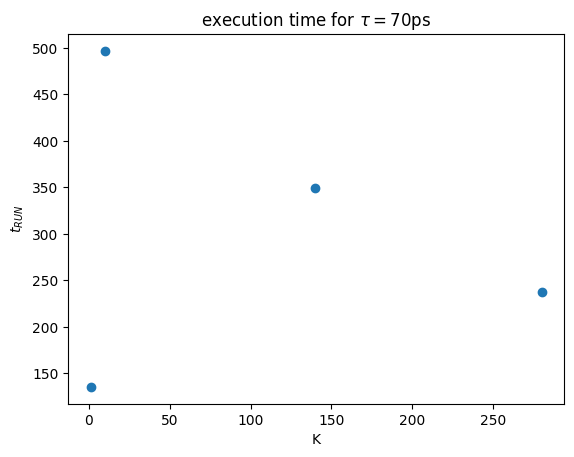

In [31]:
plt.scatter([num_steps,num_steps//2,10,1],opt_runtimes)
plt.xlabel('K')
plt.ylabel('$t_{RUN}$')
plt.title(r'execution time for $\tau =70$ps')
print(opt_runtimes)

[237.67217111587524, 348.8095018863678, 496.6549549102783, 135.54065799713135]


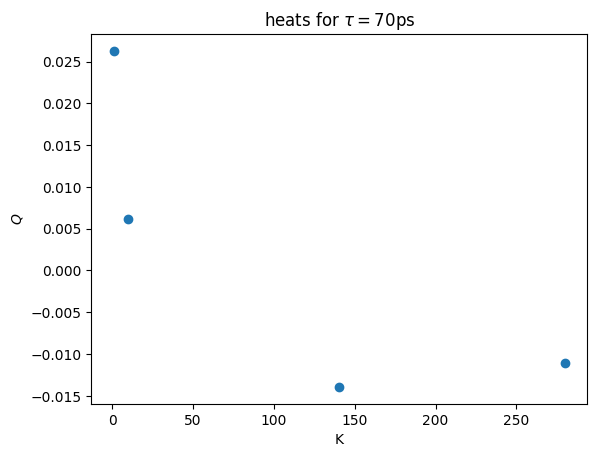

In [33]:
plt.scatter([num_steps,num_steps//2,10,1],min_heats)
plt.xlabel('K')
plt.ylabel('$Q$')
plt.title(r'heats for $\tau=70$ps')
print(opt_runtimes)

/var/folders/s8/7dsl0tws32199pt1sh7flrsw0000gn/T/ipykernel_19790/1297922773.py:59: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


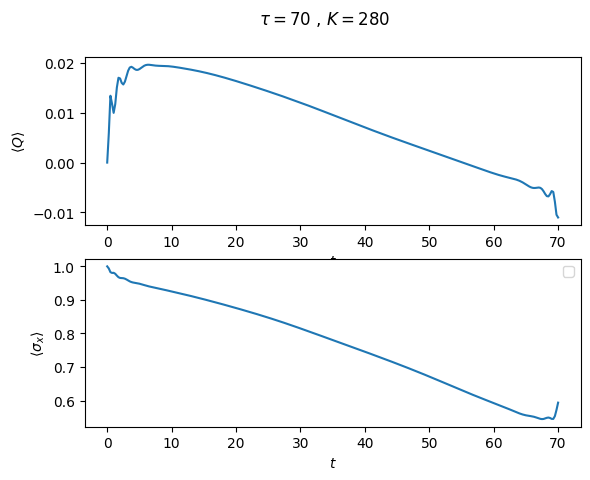

[[0.49996017-1.20915274e-12j 0.29697554-1.76835888e-12j]
 [0.29697554+2.51871358e-12j 0.49996017+2.13444669e-12j]]


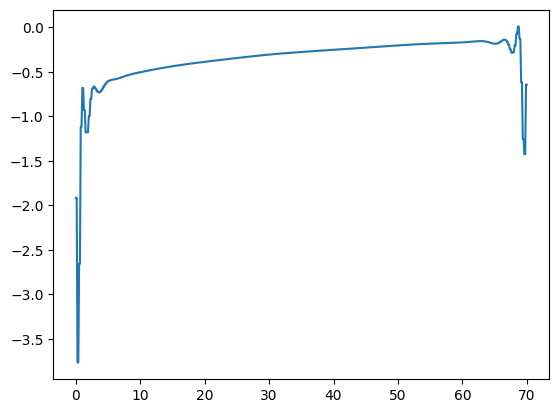

/var/folders/s8/7dsl0tws32199pt1sh7flrsw0000gn/T/ipykernel_19790/1297922773.py:59: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


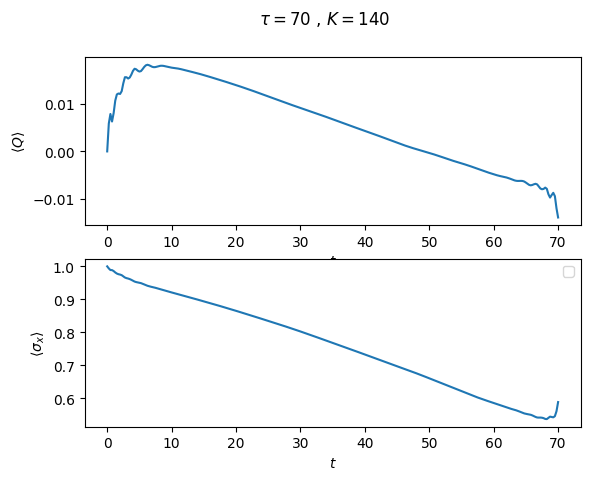

[[0.49995949-5.34737850e-13j 0.29422199-2.48998179e-12j]
 [0.29422199+3.19327999e-12j 0.49995949+1.47574417e-12j]]


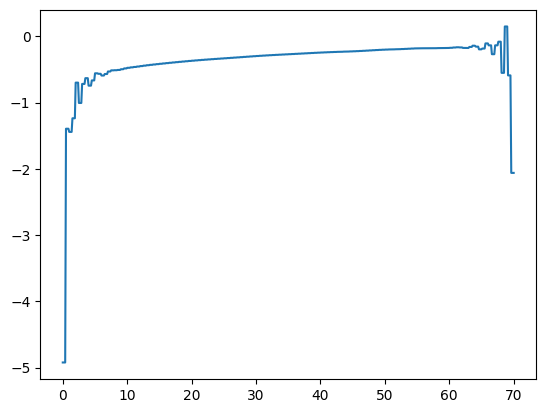

/var/folders/s8/7dsl0tws32199pt1sh7flrsw0000gn/T/ipykernel_19790/1297922773.py:59: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


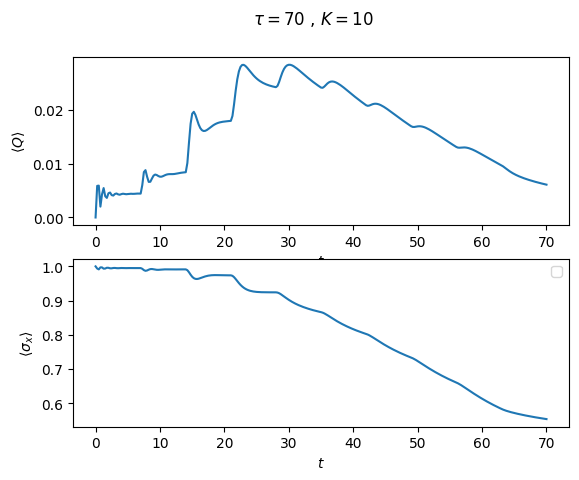

[[0.49996927-2.38485081e-12j 0.27678361+5.08562492e-13j]
 [0.27678361+5.48460955e-14j 0.49996927+3.02706300e-12j]]


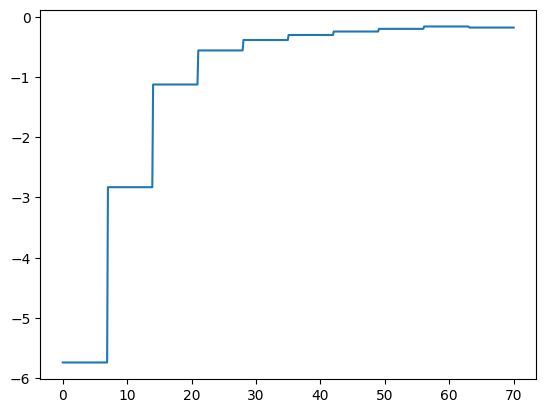

/var/folders/s8/7dsl0tws32199pt1sh7flrsw0000gn/T/ipykernel_19790/1297922773.py:59: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


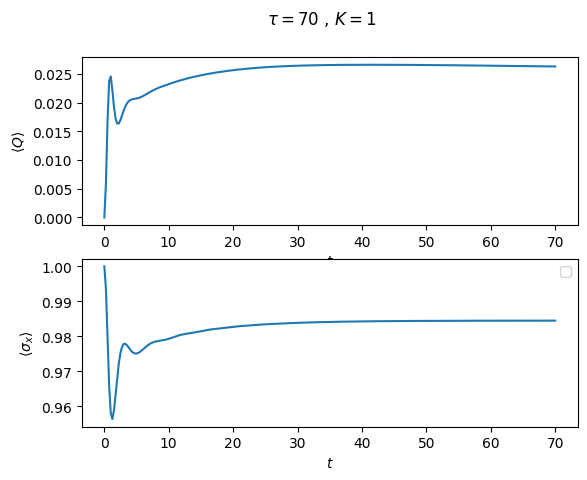

[[0.49999588-1.41358004e-13j 0.49224541-2.00157722e-13j]
 [0.49224541-2.21987309e-13j 0.49999588-1.45449497e-13j]]


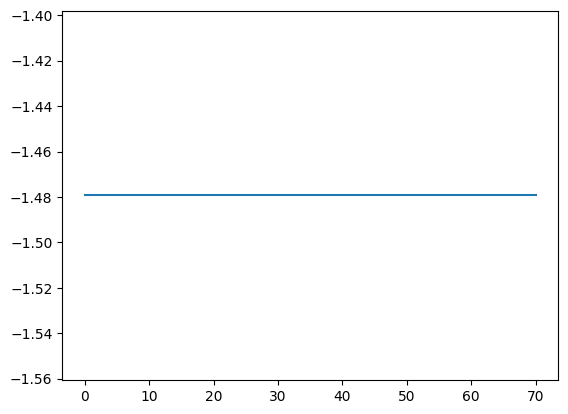

In [42]:
opt_grad_dict={protocol_times[0]:[],
                 protocol_times[1]:[], 
                 protocol_times[2]:[],
                 protocol_times[3]:[],
                 protocol_times[4]:[]}


for num_divisions in [num_steps,num_steps//2,10,1]:
    fig,axs=plt.subplots(2)
    fig.suptitle(r'$\tau={0}$ , $K={1}$'.format(t_prot,num_divisions))

    opt_steps=division_indices(num_divisions,num_steps) 
    paras=opt_dict[num_divisions].x

    result=[]
    result.extend([paras[0]]* 2*opt_steps[0])
    
    # Convert K-controls to list over 2N timesteps
    for i in range(1,len(paras)):
        step_diff = opt_steps[i] - opt_steps[i-1]
        repeat_times = 2 * step_diff
        result.extend([paras[i]] * repeat_times)

    # Convert to numpy array
    control_params=np.vstack((result))
    
    grad_res_opt = oqupy.state_gradient(
        system=system,
        initial_state=Rho_0,
        target_derivative=target_derivative,
        process_tensors=[process_tensor_var],
        num_steps=num_steps,
        parameters=control_params,
        progress_type='silent')

    dynamics=grad_res_opt['dynamics']
    t, s_x = dynamics.expectations(op.sigma('x'), real=True)

    grad_res_opt_cf = oqupy.state_gradient(
        system=system,
        initial_state=Rho_0,
        target_derivative=target_derivative,
        process_tensors=[process_tensor_varcf],
        num_steps=num_steps,
        parameters=control_params,
        progress_type='silent')

    dynamicscf=grad_res_opt_cf['dynamics']
    heats=dynamicscf.states.trace(axis1=1,axis2=2).imag/u

    opt_grad_dict[t_prot]=grad_res_opt_cf

    axs[0].plot(t,heats,label=t_prot)
    axs[0].set_xlabel(r'$t$')
    axs[0].set_ylabel(r'$\langle Q \rangle$')
    axs[1].plot(t,s_x)
    axs[1].set_xlabel(r'$t$')
    axs[1].set_ylabel(r'$\langle \sigma_x \rangle$')
    plt.legend()
    plt.show()
    print(dynamics.states[-1])

    plt.plot(np.linspace(0,t_prot,len(control_params)),control_params)
    plt.show()

# Landauer erasure in the strong coupling regime inheritly requires a Non-Markovian control in order 

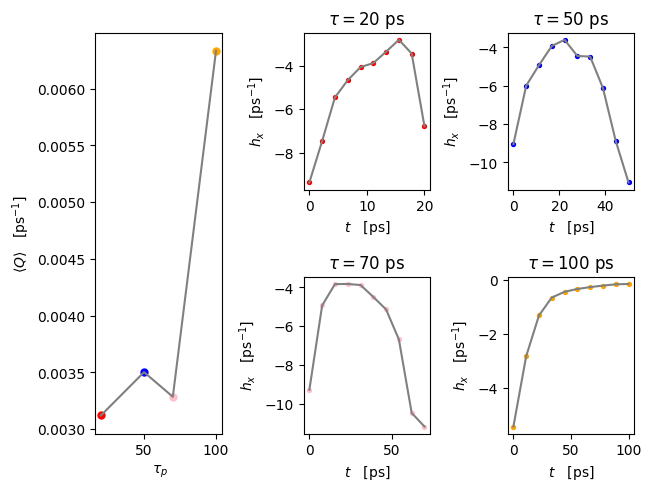

In [30]:
import matplotlib.gridspec as gridspec


cs=['red','blue','pink','orange','green']
final_heats=[]

fig = plt.figure(constrained_layout=True)
gs = gridspec.GridSpec(2, 3, figure=fig)

# Large plot on the left
ax1 = fig.add_subplot(gs[:, 0])

# 2x2 grid on the right
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])
ax4 = fig.add_subplot(gs[1, 1])
ax5 = fig.add_subplot(gs[1, 2])

graphpositions={20:ax2,
                50:ax3,
                70:ax4,
                100:ax5}

u=0.01
for i,t_prot in enumerate([20,50,70,100]):
    dynamicscf=opt_grad_dict[t_prot]['dynamics']
    heats=dynamicscf.states.trace(axis1=1,axis2=2).imag/u
    final_heats.append(heats[-1])
    ax1.scatter(t_prot,heats[-1],s=25,c=cs[i])
    axs=graphpositions[t_prot]
    opt_res=opt_dict[t_prot]
    axs.set_title(r'$\tau={0}$ ps'.format(t_prot))
    axs.scatter(np.linspace(0,t_prot,len(opt_res.x)),opt_res.x,s=8,c=cs[i])
    axs.plot(np.linspace(0,t_prot,len(opt_res.x)),opt_res.x,c='gray')
    axs.set_xlabel(r'$t \quad[\text{ps}]$')
    axs.set_ylabel(r'$h_x \quad[\text{ps}^{-1}]$')


ax1.plot([20,50,70,100],final_heats,c='gray')
ax1.set_xlabel(r' $\tau_p$ ')
ax1.set_ylabel(r'$\langle Q \rangle \quad[\text{ps}^{-1}]$')
plt.show()

# course graining
# 